# Домашнее задание: Метрики и функции потерь в регрессии
## Выполнил: Величко Кирилл Андреевич
## Датасет: scikit-learn/auto-mpg

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, SGDRegressor, HuberRegressor

In [2]:
df = load_dataset("scikit-learn/auto-mpg")["train"].to_pandas()
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

auto-mpg.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/398 [00:00<?, ? examples/s]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
df = df.dropna()

# Шаг 3: Подготовка данных

In [4]:
X = df.drop(columns=["mpg"])
y = df["mpg"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print(len(X_train), len(X_val), len(X_test))

238 80 80


In [5]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

In [7]:
y_mean = y_train.mean()
y_median = y_train.median()

def evaluate_baseline(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

baseline_mean_pred = np.full_like(y_val, y_mean)
baseline_median_pred = np.full_like(y_val, y_median)

metrics_mean = evaluate_baseline(y_val, baseline_mean_pred)
metrics_median = evaluate_baseline(y_val, baseline_median_pred)

metrics_mean, metrics_median

((7.234726890756302, np.float64(8.728829949256136), -0.025647749905760575),
 (7.28875, np.float64(8.971816984312598), -0.08354506269809225))

In [8]:
lr_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred = lr_pipeline.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
rmse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

mae, rmse, r2

(5.612800466610894, 53.22137728807276, 0.2835724550369456)

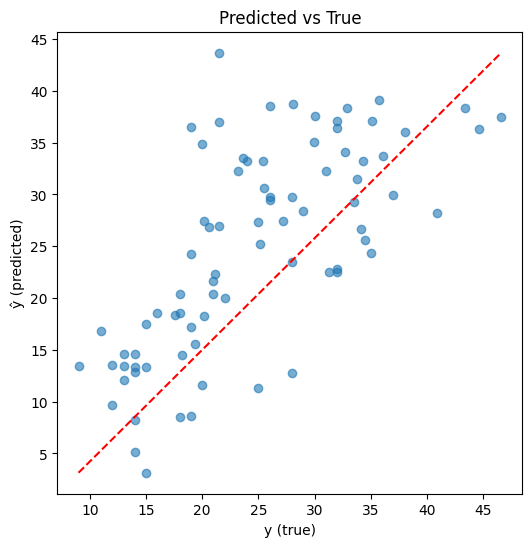

In [26]:
# диаграмма соответствия `ŷ` и `y` с линией `y = x`
# значения лежат сравнительно близко к линии, но есть выбросы

plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_pred.min(), y_pred.max()], 'r--')
plt.xlabel("y (true)")
plt.ylabel("ŷ (predicted)")
plt.title("Predicted vs True")
plt.show()

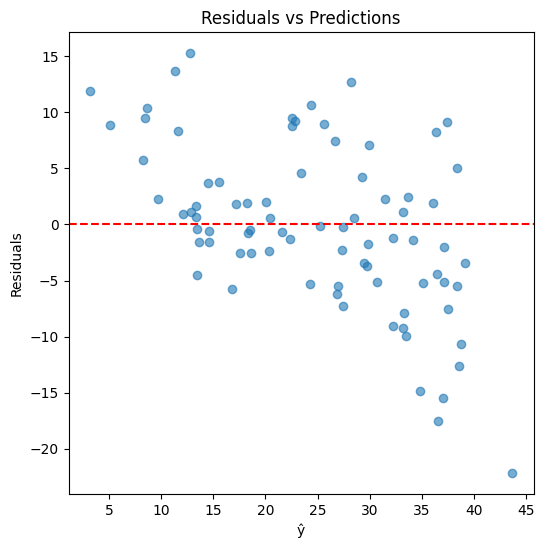

In [29]:
# график остатков `r = y − ŷ` в зависимости от `ŷ`

# разброс увеличивается с ростом ŷ
# есть выбросы

residuals = y_val - y_pred

plt.figure(figsize=(6,6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("ŷ")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()

In [32]:
mse_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", SGDRegressor(loss="squared_error", random_state=42, max_iter=10000))
])

mae_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", SGDRegressor(loss="epsilon_insensitive", random_state=42, max_iter=10000))
])

mse_model.fit(X_train, y_train)
mae_model.fit(X_train, y_train)

pred_mse = mse_model.predict(X_val)
pred_mae = mae_model.predict(X_val)

results = pd.DataFrame({
    "Model": ["MSE", "MAE"],
    "MAE": [
        mean_absolute_error(y_val, pred_mse),
        mean_absolute_error(y_val, pred_mae)
    ],
    "RMSE": [
        mean_squared_error(y_val, pred_mse),
        mean_squared_error(y_val, pred_mae)
    ],
    "R2": [
        r2_score(y_val, pred_mse),
        r2_score(y_val, pred_mae)
    ]
})

results

,Model,MAE,RMSE,R2
0,MSE,5.889702,59.826015,0.194666
1,MAE,10.087308,152.228488,-1.049189


Как видно на графике, в данных присутствуют выбросы, да и сами данные распределены "недостаточно кучно".
Из-за выбросов MSE и MAE показали себя хуже обычной линейной регрессии.
Увеличение количества итераций также особо не повлияло на результат

In [33]:
final_model = lr_pipeline
final_model.fit(X_train_val, y_train_val)

test_pred = final_model.predict(X_test)

mae_test = mean_absolute_error(y_test, test_pred)
rmse_test = mean_squared_error(y_test, test_pred)
r2_test = r2_score(y_test, test_pred)

mae_test, rmse_test, r2_test

(5.198912462819732, 44.405235756606835, 0.17410874405084997)

In [34]:
huber_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", HuberRegressor(max_iter=3000)) # не уложилась в 2000 итераций (Increase the number of iterations (max_iter) or scale the data as shown in)
])

huber_model.fit(X_train, y_train)
pred_huber = huber_model.predict(X_val)

mean_absolute_error(y_val, pred_huber), mean_squared_error(y_val, pred_huber), r2_score(y_val, pred_huber)

(3.1155226906479427, 16.020382244246363, 0.7843452442335179)

In [35]:
summary = pd.DataFrame({
    "Model": ["Baseline Mean", "Baseline Median", "LinearRegression", "MSE", "MAE", "Huber"],
    "MAE": [
        metrics_mean[0],
        metrics_median[0],
        mae,
        results.loc[0,"MAE"],
        results.loc[1,"MAE"],
        mean_absolute_error(y_val, pred_huber)
    ],
    "RMSE": [
        metrics_mean[1],
        metrics_median[1],
        rmse,
        results.loc[0,"RMSE"],
        results.loc[1,"RMSE"],
        mean_squared_error(y_val, pred_huber)
    ],
    "R2": [
        metrics_mean[2],
        metrics_median[2],
        r2,
        results.loc[0,"R2"],
        results.loc[1,"R2"],
        r2_score(y_val, pred_huber)
    ]
})

summary

,Model,MAE,RMSE,R2
0,Baseline Mean,7.234727,8.728830,-0.025648
1,Baseline Median,7.288750,8.971817,-0.083545
2,LinearRegression,5.612800,53.221377,0.283572
3,MSE,5.889702,59.826015,0.194666
4,MAE,10.087308,152.228488,-1.049189
5,Huber,3.115523,16.020382,0.784345


# Анализ таблицы

- Бейзлайны показывают высокие ошибки и отрицательный R² -> простое среднее или медиана не объясняет вариацию данных.
- LinearRegression улучшает MAE и R² по сравнению с бейзлайнами -> модель способна объяснять часть вариации, но RMSE всё ещё чувствителен к выбросам.
- MSE-модель (квадратичная ошибка) близка к LinearRegression по MAE, но более чувствительна к выбросам -> RMSE высокий.
- MAE-модель (абсолютная ошибка) оптимизировалась по L1 (минимизация модулей ошибок) -> MAE выше, R² отрицательный, RMSE очень большой -> плохо справляется с выбросами и шумом.
- Huber-модель сочетает преимущества MSE и MAE -> лучшая стабильность, наименьшие MAE и RMSE, высокий R² = 0.78 -> объясняет ~78% дисперсии.